In [2]:
pip install opencv-python numpy mediapipe

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
    --------------------------------------- 0.3/10.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.6 MB 913.1 kB/s eta 0:00:12
   - -------------------------------------- 0.5/10.6 MB 913.1 kB/s eta 0:00:12
   -- ------------------------------------- 0.8/10.6 MB 867.9 kB/s eta 0:00:12
   --- ------------------------------------ 1.0/10.6 MB 968.2 kB/s eta 0:00:10
   ---- ----------------------------------- 1.3/10.6 MB 1.0 MB/s eta 0:00:10
   ----- ---------------------------------- 1.6/10.6 MB 1.0 MB/s eta 0:00:09
   ----- ---------------------------------- 1.6/10.6 MB 1.0 MB/s eta 0:00:09
   ------ --------------------------------- 1.8/10.6 MB 928.1 kB/s eta 0:00:10
   ------- -------------

In [1]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()   # ✅ MUST be indented

    if not ret:
        break

    cv2.imshow("Frame", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

In [6]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()  # Added indentation here
    if not ret:
        break
        
    cv2.imshow('Frame', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

In [8]:
import cv2
import numpy as np
import time

# Initialize camera
cap = cv2.VideoCapture(0)
prev_time = 0

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not grab frame.")
        break

    # Reset detection count for each frame
    detected_count = 0

    # 1. Convert to HSV color space for better color detection
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 2. Define green range to detect (adjust if needed for your setup)
    lower_green = np.array([40, 50, 50])
    upper_green = np.array([80, 255, 255])

    # 3. Create a mask that highlights green objects
    mask = cv2.inRange(hsv, lower_green, upper_green)

    # 4. Find outlines (contours) of detected objects
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for contour in contours:
        # Filter out small noise; only count if object is large enough
        if cv2.contourArea(contour) > 500:
            detected_count += 1

            # Get coordinates for the bounding box
            x, y, w, h = cv2.boundingRect(contour)

            # Draw green bounding box around larvae
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(frame, "Larvae Cluster", (x, y - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 5. Calculate FPS (Frames Per Second)
    current_time = time.time()
    time_diff = current_time - prev_time
    fps = 1 / time_diff if time_diff > 0 else 0
    prev_time = current_time

    # 6. Overlay Stats on screen
    cv2.putText(frame, f"FPS: {int(fps)}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f"Detected: {detected_count}", (10, 70), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

    # 7. Show video window
    cv2.imshow("BSF Nutrifeed Monitor", frame)

    # Press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

In [9]:
import cv2
import numpy as np
import time
import csv
import datetime

# 1. Classification function (Must be defined at the top)
def classify_condition(count):    
    if count >= 5:    
        return "Healthy Growth"    
    elif count >= 2:    
        return "Low Density"    
    else:    
        return "Possible Contamination"

# 2. Setup Camera and CSV
cap = cv2.VideoCapture(0)
prev_time = 0
log_interval = 5  # Log data every 5 seconds
last_log_time = time.time()

# Create the CSV file and write the header
with open("bsf_monitor_log.csv", "w", newline="") as f:    
    writer = csv.writer(f)    
    writer.writerow(["Timestamp", "Detected Count", "Condition", "FPS"])

print("Monitoring started... Press 'q' to stop.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    detected_count = 0
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Larvae Color Detection (Beige/Cream)
    lower_larvae = np.array([0, 20, 100]) 
    upper_larvae = np.array([30, 150, 255])
    mask = cv2.inRange(hsv, lower_larvae, upper_larvae)
    
    # Find and count contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        if cv2.contourArea(contour) > 500:
            detected_count += 1
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # 3. Determine Health Condition
    condition = classify_condition(detected_count)

    # 4. Calculate FPS
    current_time = time.time()
    fps = 1 / (current_time - prev_time) if (current_time - prev_time) > 0 else 0
    prev_time = current_time

    # 5. Display Stats and Condition on Screen
    cv2.putText(frame, f"FPS: {int(fps)}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.putText(frame, f"Detected: {detected_count}", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(frame, f"Status: {condition}", (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

    # 6. Logging Logic (Runs every 5 seconds)
    if time.time() - last_log_time >= log_interval:    
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")    
        with open("bsf_monitor_log.csv", "a", newline="") as f:    
            writer = csv.writer(f)    
            writer.writerow([timestamp, detected_count, condition, int(fps)])    
        last_log_time = time.time()    
        print(f"Logged: {timestamp} | {condition} | {detected_count} Larvae")

    cv2.imshow("BSF Nutrifeed Monitor", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Monitoring started... Press 'q' to stop.
Logged: 2026-03-27 02:20:10 | Low Density | 4 Larvae
Logged: 2026-03-27 02:20:15 | Healthy Growth | 5 Larvae
Logged: 2026-03-27 02:20:20 | Low Density | 4 Larvae
Logged: 2026-03-27 02:20:26 | Low Density | 4 Larvae
Logged: 2026-03-27 02:20:31 | Low Density | 4 Larvae
Logged: 2026-03-27 02:20:36 | Low Density | 4 Larvae
Logged: 2026-03-27 02:20:41 | Healthy Growth | 5 Larvae
Logged: 2026-03-27 02:20:46 | Healthy Growth | 5 Larvae
Logged: 2026-03-27 02:20:51 | Healthy Growth | 5 Larvae
Logged: 2026-03-27 02:20:56 | Healthy Growth | 5 Larvae
Logged: 2026-03-27 02:21:01 | Healthy Growth | 5 Larvae
Logged: 2026-03-27 02:21:06 | Healthy Growth | 5 Larvae
Logged: 2026-03-27 02:21:11 | Healthy Growth | 5 Larvae
Logged: 2026-03-27 02:21:16 | Healthy Growth | 6 Larvae
Logged: 2026-03-27 02:21:21 | Healthy Growth | 6 Larvae
Logged: 2026-03-27 02:21:26 | Healthy Growth | 6 Larvae
Logged: 2026-03-27 02:21:31 | Healthy Growth | 7 Larvae
Logged: 2026-03-27 02:

KeyboardInterrupt: 

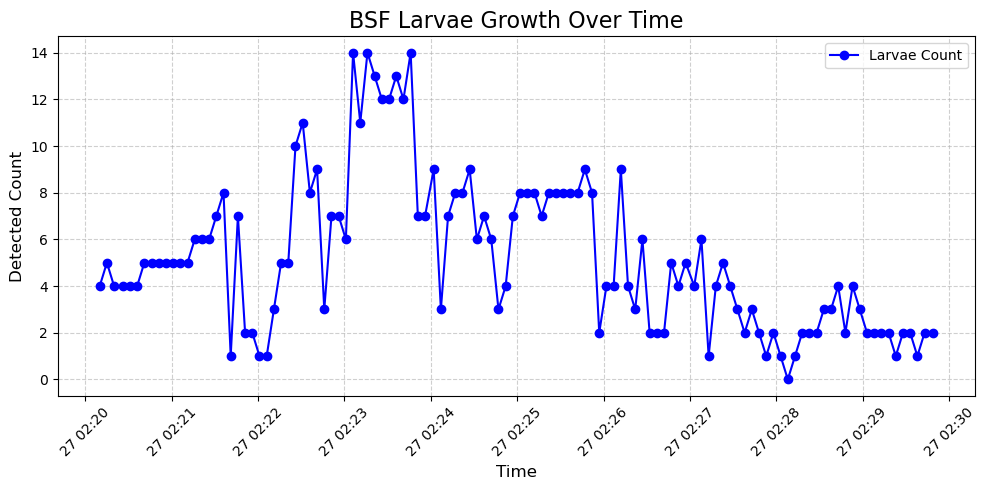

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data from your CSV file
try:
    df = pd.read_csv('bsf_monitor_log.csv')

    # 2. Convert the 'Timestamp' column to a format Python understands
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

    # 3. Set up the graph
    plt.figure(figsize=(10, 5))
    plt.plot(df['Timestamp'], df['Detected Count'], marker='o', linestyle='-', color='b', label='Larvae Count')

    # 4. Add labels and a title
    plt.title('BSF Larvae Growth Over Time', fontsize=16)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Detected Count', fontsize=12)
    plt.xticks(rotation=45)  # Rotate dates for better readability
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # 5. Show the plot
    plt.tight_layout()
    plt.show()

    # Optional: Save the plot as an image
    # plt.savefig('bsf_larvae_growth_chart.png')

except FileNotFoundError:
    print("The log file was not found. Make sure you've run the monitor script first!")

In [2]:
#SMART ALERT
#a second black window will appear.
#pitch black: It means the larvae aren't being detected as "Green." 
#white blobs: means those are the larvae! If there are white blobs but the Count is still 0, it means the blobs are too small (less than 100 pixels).import cv2

import numpy as np
import time
import datetime
import os

# 1. Setup Folders and Functions
if not os.path.exists("alerts"):
    os.makedirs("alerts")

def classify_condition(count):    
    if count >= 5: return "Healthy Growth"    
    elif count >= 2: return "Low Density"    
    else: return "Possible Contamination"

# 2. Setup Variables
cap = cv2.VideoCapture(0)
prev_time = 0
log_interval = 5
last_log_time = time.time()
alert_threshold_seconds = 10
contamination_start_time = None 
snapshot_taken = False

print("System Starting... Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret: break

    detected_count = 0
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 3. DETECTION SETTINGS (Wider green range for better sensitivity)
    lower_green = np.array([35, 40, 40]) 
    upper_green = np.array([90, 255, 255])
    
    mask = cv2.inRange(hsv, lower_green, upper_green)
    
    # IMPORTANT: This window shows you what the camera "sees" in color
    cv2.imshow('DEBUG: Mask', mask) 

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for contour in contours:
        # Reduced area to 100 to catch smaller larvae
        if cv2.contourArea(contour) > 100: 
            detected_count += 1
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # 4. MONITORING LOGIC
    condition = classify_condition(detected_count)
    
    current_time = time.time()
    fps = 1 / (current_time - prev_time) if (current_time - prev_time) > 0 else 0
    prev_time = current_time

    # 5. SMART ALERT & SNAPSHOT LOGIC
    if condition == "Possible Contamination":
        if contamination_start_time is None:
            contamination_start_time = time.time()
        
        elapsed_time = time.time() - contamination_start_time
        
        if elapsed_time >= alert_threshold_seconds:
            # Visual Alert
            cv2.rectangle(frame, (0, 0), (frame.shape[1], frame.shape[0]), (0, 0, 255), 10)
            cv2.putText(frame, "!!! ALERT: CRITICAL LOW DENSITY !!!", (50, 250), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
            
            # Take Snapshot once per alert
            if not snapshot_taken:
                ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
                cv2.imwrite(f"alerts/alert_{ts}.jpg", frame)
                snapshot_taken = True
                print(f"Alert Snapshot Saved: alert_{ts}.jpg")
    else:
        contamination_start_time = None
        snapshot_taken = False

    # 6. ON-SCREEN DISPLAY
    cv2.putText(frame, f"Status: {condition}", (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    cv2.putText(frame, f"Count: {detected_count}", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    
    cv2.imshow("BSF Nutrifeed Monitor", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

System Starting... Press 'q' to quit.
Alert Snapshot Saved: alert_20260327_032715.jpg
Alert Snapshot Saved: alert_20260327_032801.jpg
Alert Snapshot Saved: alert_20260327_033023.jpg
Alert Snapshot Saved: alert_20260327_033054.jpg
Alert Snapshot Saved: alert_20260327_033106.jpg
Alert Snapshot Saved: alert_20260327_033157.jpg
Alert Snapshot Saved: alert_20260327_033250.jpg


KeyboardInterrupt: 

In [14]:
#Snap shot 
import cv2
import numpy as np
import time
import datetime
import os

# Create a folder for alerts if it doesn't exist
if not os.path.exists("alerts"):
    os.makedirs("alerts")

# --- Alert Variables ---
alert_threshold_seconds = 10
contamination_start_time = None 
alert_active = False
snapshot_taken = False  # Track if we already took a photo for the current alert

# ... [Inside your while loop, after calculating 'condition'] ...

if condition == "Possible Contamination":
    if contamination_start_time is None:
        contamination_start_time = time.time()
    
    elapsed_time = time.time() - contamination_start_time
    
    if elapsed_time >= alert_threshold_seconds:
        alert_active = True
        
        # 1. VISUAL ALARM
        cv2.rectangle(frame, (0, 0), (frame.shape[1], frame.shape[0]), (0, 0, 255), 10)
        cv2.putText(frame, "!!! ALERT: CRITICAL LOW DENSITY !!!", (50, 250), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
        
        # 2. SNAPSHOT LOGIC
        if not snapshot_taken:
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            file_name = f"alerts/alert_{timestamp}.jpg"
            
            # Save the current frame as an image
            cv2.imwrite(file_name, frame)
            print(f"CRITICAL ALERT! Snapshot saved to {file_name}")
            
            snapshot_taken = True  # Set to True so it doesn't take 30 photos a second

else:
    # Reset everything when larvae return
    contamination_start_time = None
    alert_active = False
    snapshot_taken = False  # Ready to take a new photo if another alert happens